In [1]:
!pip3 install numpy matplotlib plotly nbformat


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Cell 2: Thư viện cần thiết
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math


In [3]:
# Cell 3: Đọc dữ liệu
df = pd.read_csv('customer_data1.csv')
df.head(12)


,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,5
5,6,38,Male,7347,Bachelor,South,Silver,occasional,2822,Electronics,5
6,7,32,Female,8265,Bachelor,South,Silver,frequent,3293,Clothing,7
7,8,24,Female,47773,HighSchool,North,Regular,rare,21794,Books,5
8,9,27,Male,19154,College,East,Regular,occasional,5819,Clothing,5
9,10,28,Female,24666,HighSchool,North,Regular,rare,8779,Food,6


In [4]:
# Cell 4: Tiền xử lý
df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id']).head(10000)
print(df)


      age  income  purchase_amount  satisfaction_score
0      27   40682            18249                   6
1      29   15317             4557                   6
2      37   38849            11822                   6
3      30   11568             4098                   7
4      31   46952            19685                   5
...   ...     ...              ...                 ...
9995   25   10455             4265                   5
9996   28   42935            18728                   6
9997   27   21252             5940                   4
9998   35   36017            12173                   3
9999   27   41353            15041                   5

[10000 rows x 4 columns]


In [5]:
class KMeans:
    def __init__(self, n_clusters, data):
        self.k = n_clusters
        self.x = np.array(data)  # Đảm bảo dữ liệu là numpy.ndarray
        self.d = self.x.shape[1]  # Số chiều dữ liệu
        self.centroids = np.zeros((self.k, self.d))

        # Khởi tạo centroid ngẫu nhiên trong phạm vi dữ liệu
        for i in range(self.d):
            self.centroids[:, i] = np.random.uniform(np.min(self.x[:, i]), np.max(self.x[:, i]), size=self.k)

        self.labels = self.genLabels()
        self.colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'black', 4: 'purple', 5: 'orange', 6: 'brown'}

    def dist(self, p, q):
        return np.linalg.norm(p - q)  # Khoảng cách Euclidean

    def predict(self, p):
        return np.argmin([self.dist(p, centroid) for centroid in self.centroids])

    def genLabels(self):
        return np.array([self.predict(p) for p in self.x])

    def fit(self, epochs, step):
            print(f"\nFitting for {epochs} epochs with step of {step}")
            for epoch in range(epochs):
                for i, centroid in enumerate(self.centroids):
                    l = np.array([1 if item == i else 0 for item in self.labels])
                    
                    if np.sum(l) > 0:  # Tránh lỗi chia cho 0
                        temp = np.sum((self.x - centroid) * l[:, np.newaxis], axis=0) / np.sum(l)
                        self.centroids[i] += step * temp

                # Cập nhật nhãn mới
                self.labels = self.genLabels()

            print("Done fitting!\n")

    def showPlot(self, classification=False): # Dành cho 2 chiều

        if self.x.shape[1] != 2:
            print("Dữ liệu không phải 2 chiều, không thể hiển thị biểu đồ.")
            return
        
        plt.figure(figsize=(50, 50))

        if classification:
            handles = []  # Danh sách biểu tượng cho chú thích

            for i, p in enumerate(self.x):
                plt.scatter(p[0], p[1], color=self.colors[self.labels[i]])

            for i, centroid in enumerate(self.centroids):
                plt.scatter(centroid[0], centroid[1], color=self.colors[i], s=200, marker="o", linewidths=3, edgecolor='gray')
                
                # Thêm vào danh sách chú thích
                handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                        markerfacecolor=self.colors[i], markersize=10,
                                        label=f"Cluster {i}"))

            # Hiển thị chú thích ở góc trên bên trái
            plt.legend(handles=handles, loc="upper left", title="Clusters")

        else:
            plt.scatter(self.x[:, 0], self.x[:, 1], color='blue')
            plt.scatter(self.centroids[:, 0], self.centroids[:, 1], color="red", s=100,  marker="x", linewidths=3, edgecolor='gray')

        plt.show()


    def printCentroids(self):
        print("=" * 20)
        print("Centroids:")
        print(self.centroids)

    def calculate_wcss(self):
        return np.sum((self.x - self.centroids[self.labels]) ** 2)
    

In [6]:
def elbow_curve(X, max_k):
    wcss_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, data=X)
        kmeans.fit(epochs=100, step=1)  # Fit the model
        wcss = kmeans.calculate_wcss()    # Calculate WCSS for this k
        wcss_values.append(wcss)

    # Plotting the elbow curve
    plt.plot(range(1, max_k + 1), wcss_values, marker='o', color='b')
    plt.title('Elbow Curve')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.show()

In [68]:
elbow_curve(df, 10)


Fitting for 100 epochs with step of 1


KeyboardInterrupt: 

In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# # # Chuẩn hóa ba cột mong muốn
# # columns_to_scale = ['income',
# #                      'age', 
# #                      'purchase_amount',
# #                      'satisfaction_score',
# #                      'promotion_usage'
# #                      ]
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(df[columns_to_scale])

# # # Đặt lại thành DataFrame
# # scaled_df = pd.DataFrame(X_scaled, columns=columns_to_scale, index=df.index)

# # # Xóa các cột cũ chưa chuẩn hóa
# # df_dropped = df.drop(columns=columns_to_scale)

# # # Ghép lại
# # df_final = pd.concat([df_dropped, scaled_df], axis=1)
# # X_scaled = df_final

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)

# print(X_scaled)

# kmeans = KMeans(n_clusters=3, data=X_scaled)
# kmeans.printCentroids()
# kmeans.fit(epochs=100,step=1)
# pred = kmeans.genLabels()
# print(pred)
# kmeans.printCentroids()

# labels = kmeans.labels

# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X_scaled, labels)

# # 7. In ra độ quan trọng của từng đặc trưng
# feature_names = df.columns
# importances = rf.feature_importances_

# # Gộp và sắp xếp
# feature_scores = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

# print("🔍 Các đặc trưng theo độ quan trọng (sử dụng Random Forest sau KMeans):\n")
# for f, score in feature_scores:
#     print(f"{f:30s}: {score:.4f}")

[[-6.67453692e-01  1.01401990e+00  1.81106876e+00 -6.49980851e-01
   9.61094820e-01]
 [-2.20727441e-01 -9.42539964e-01 -1.06146836e+00  1.53850686e+00
   9.61094820e-01]
 [ 1.56617756e+00  8.72629230e-01  4.62705036e-01 -6.49980851e-01
   9.61094820e-01]
 ...
 [-6.67453692e-01 -4.84736583e-01 -7.71319456e-01  1.53850686e+00
  -9.58790957e-01]
 [ 1.11945131e+00  6.54179495e-01  5.36343696e-01 -6.49980851e-01
  -1.91873385e+00]
 [-6.67453692e-01  1.06577829e+00  1.13804078e+00  1.53850686e+00
   1.15193147e-03]]
Centroids:
[[-0.56001734 -0.355702   -1.37263647  1.28023678  2.1661444 ]
 [-3.64728888  1.64428131 -0.74835448  1.01591213 -1.02723413]
 [ 1.5243485  -1.35086403  0.77677717  0.13950929 -1.67336208]]

Fitting for 100 epochs with step of 1
Done fitting!

[1 0 2 ... 0 2 1]
Centroids:
[[ 0.016015   -0.96061271 -0.93035825  0.03048172  0.00619964]
 [-0.76495347  0.75572357  0.73675232  0.20616365 -0.02329106]
 [ 0.86209441  0.73651495  0.70770483 -0.29084009  0.01664678]]
🔍 Các đặc 

[[ 2.00158765  0.25463832 -1.13438257  0.56514287]
 [-1.42121235  0.49925913 -0.84358806 -0.08231349]
 [ 0.90375414  1.80414226  0.44518442 -0.28688522]
 ...
 [-0.86570844 -1.16884955  0.19230056 -0.20503151]
 [ 0.83704775 -0.56028708  2.15134342 -0.08647042]
 [ 1.57129225 -0.43612945 -0.46344151  0.0506919 ]]
              Feature  Importance
0                 age    0.698419
1              income    0.363191
2     purchase_amount    0.353696
3  satisfaction_score    0.018896


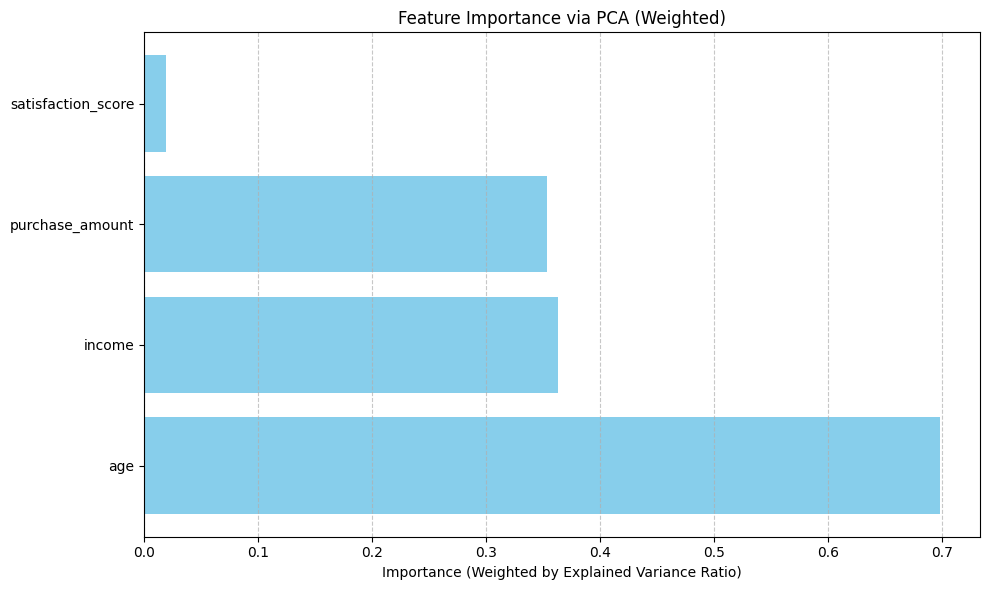

In [7]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Áp dụng PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

# Ma trận loading (các thành phần chính)
loadings = pca.components_.T

# Cách 2: Tính importance theo loading * explained_variance_ratio
importance_weighted = np.sum((np.abs(loadings).T * pca.explained_variance_ratio_).T, axis=1)

# Đưa vào DataFrame
feature_importance = pd.DataFrame({
    'Feature': df.columns,
    'Importance': importance_weighted
}).sort_values(by='Importance', ascending=False)

# In kết quả
print(feature_importance)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel("Importance (Weighted by Explained Variance Ratio)")
plt.title("Feature Importance via PCA (Weighted)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

      age  income  purchase_amount
0      27   40682            18249
1      29   15317             4557
2      37   38849            11822
3      30   11568             4098
4      31   46952            19685
...   ...     ...              ...
9995   25   10455             4265
9996   28   42935            18728
9997   27   21252             5940
9998   35   36017            12173
9999   27   41353            15041

[10000 rows x 3 columns]
[[-0.66745369  1.0140199   1.81106876]
 [-0.22072744 -0.94253996 -1.06146836]
 [ 1.56617756  0.87262923  0.46270504]
 ...
 [-0.66745369 -0.48473658 -0.77131946]
 [ 1.11945131  0.6541795   0.5363437 ]
 [-0.66745369  1.06577829  1.13804078]]
[[ 2.01051104 -0.62800884]
 [-1.41238282 -0.24878384]
 [ 0.91291559  1.58482527]
 ...
 [-0.87472944 -0.68483293]
 [ 0.81941675  1.13601337]
 [ 1.5712904  -0.63639209]]


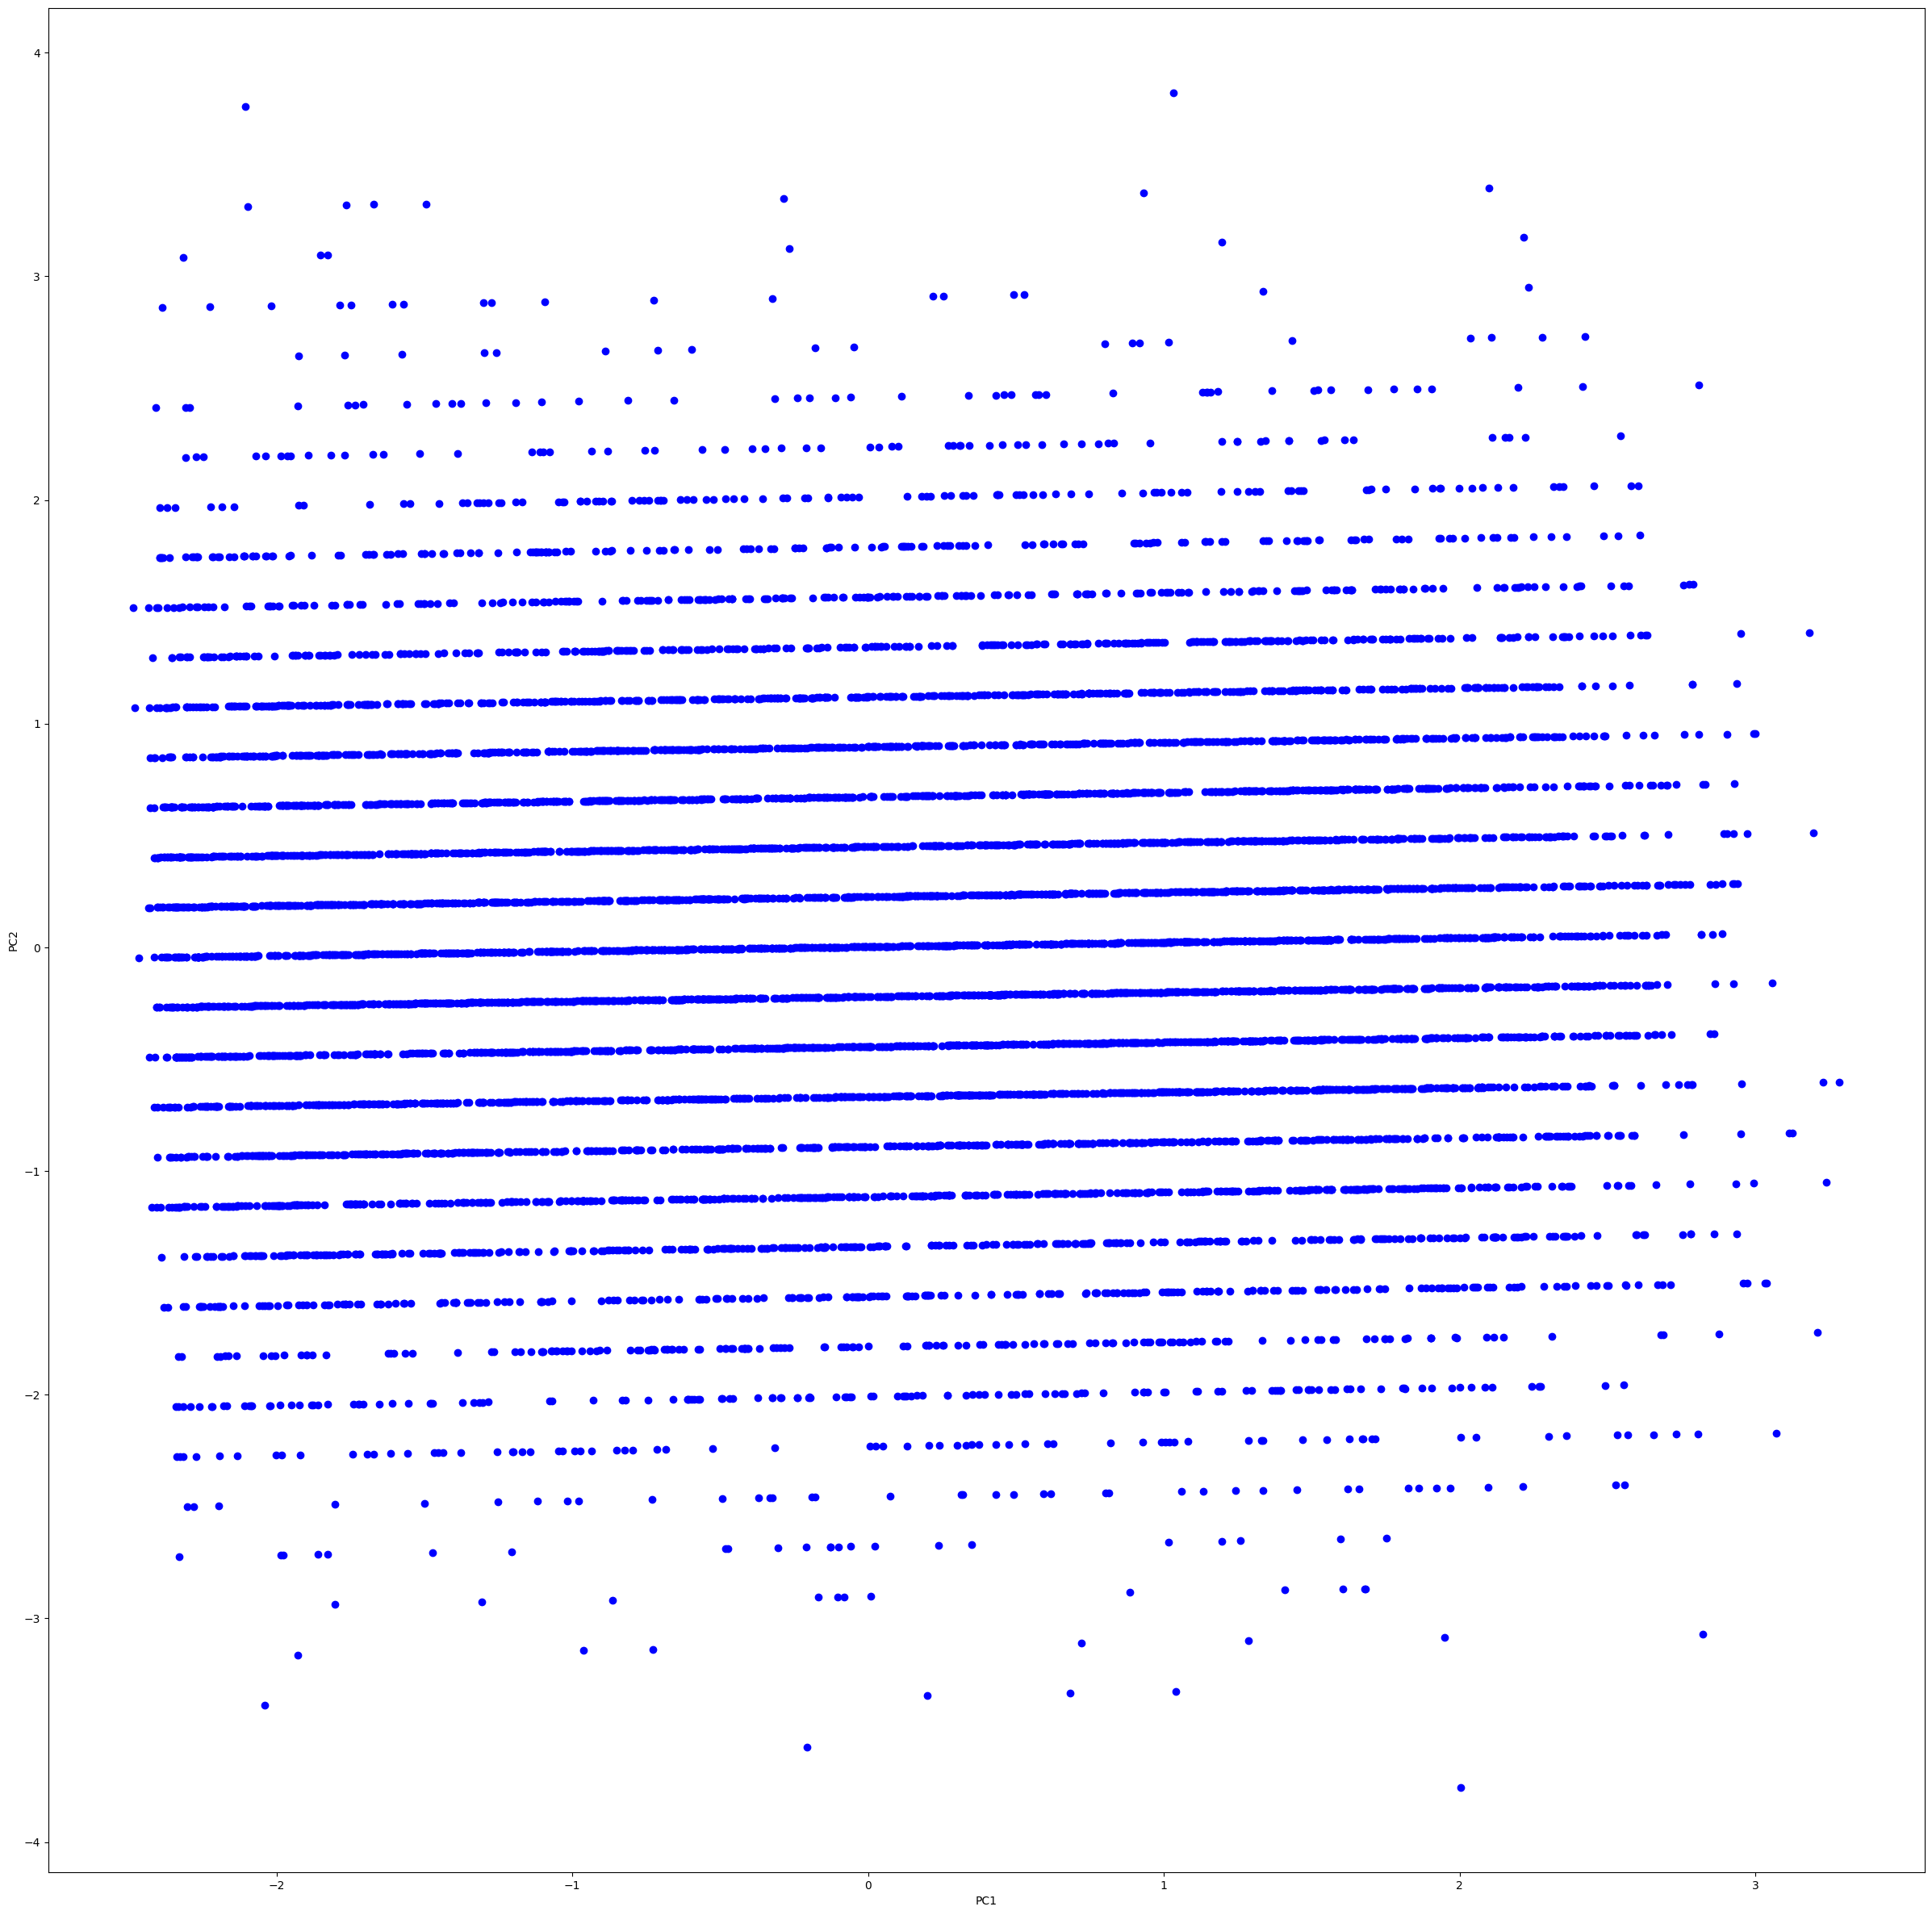

In [16]:

df_new = df.drop(columns=['satisfaction_score'])
print(df_new)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_new)
print(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

plt.figure(figsize=(30, 30))
plt.scatter(X_pca[:,0], X_pca[:,1], color='b')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


[[ 2.01051104 -0.62800884]
 [-1.41238282 -0.24878384]
 [ 0.91291559  1.58482527]
 ...
 [-0.87472944 -0.68483293]
 [ 0.81941675  1.13601337]
 [ 1.5712904  -0.63639209]]


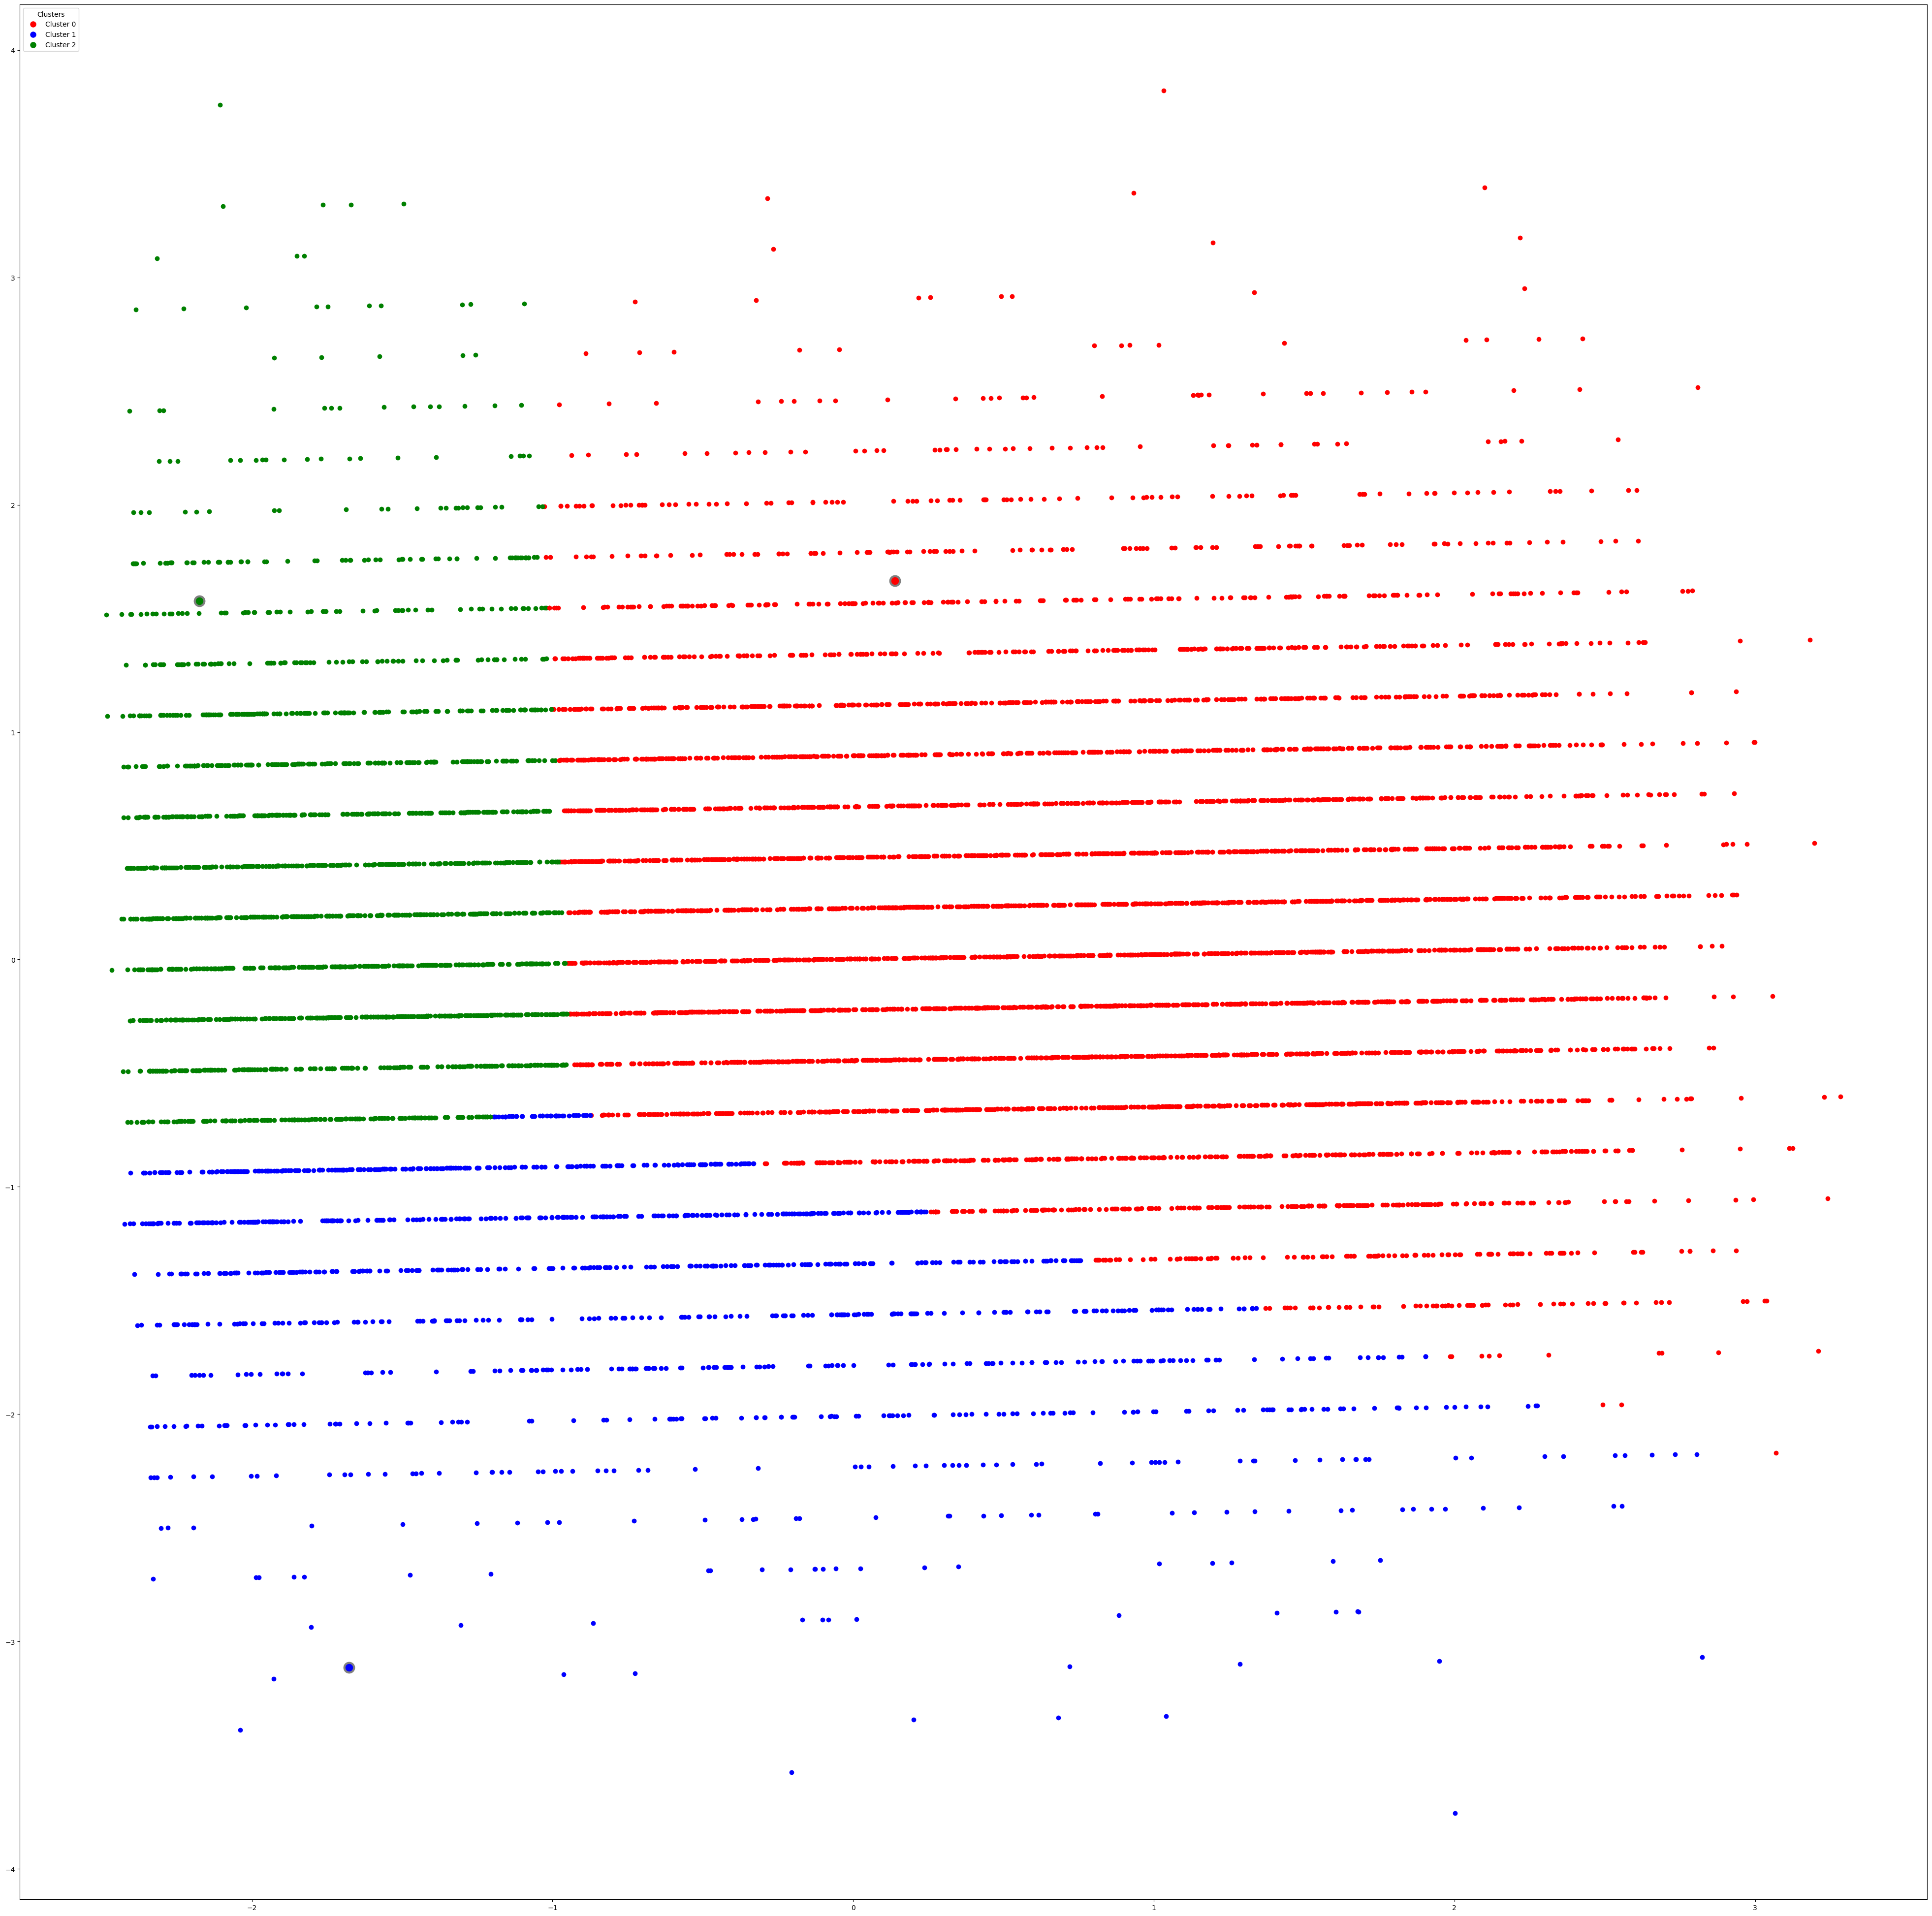

Centroids:
[[ 0.13915801  1.66473741]
 [-1.67655395 -3.11325294]
 [-2.17373788  1.5759372 ]]

Fitting for 100 epochs with step of 1
Done fitting!

[0 1 0 ... 1 0 0]
Centroids:
[[ 1.33164518  0.02616223]
 [-0.95018556 -0.87982823]
 [-1.13608588  0.8122126 ]]


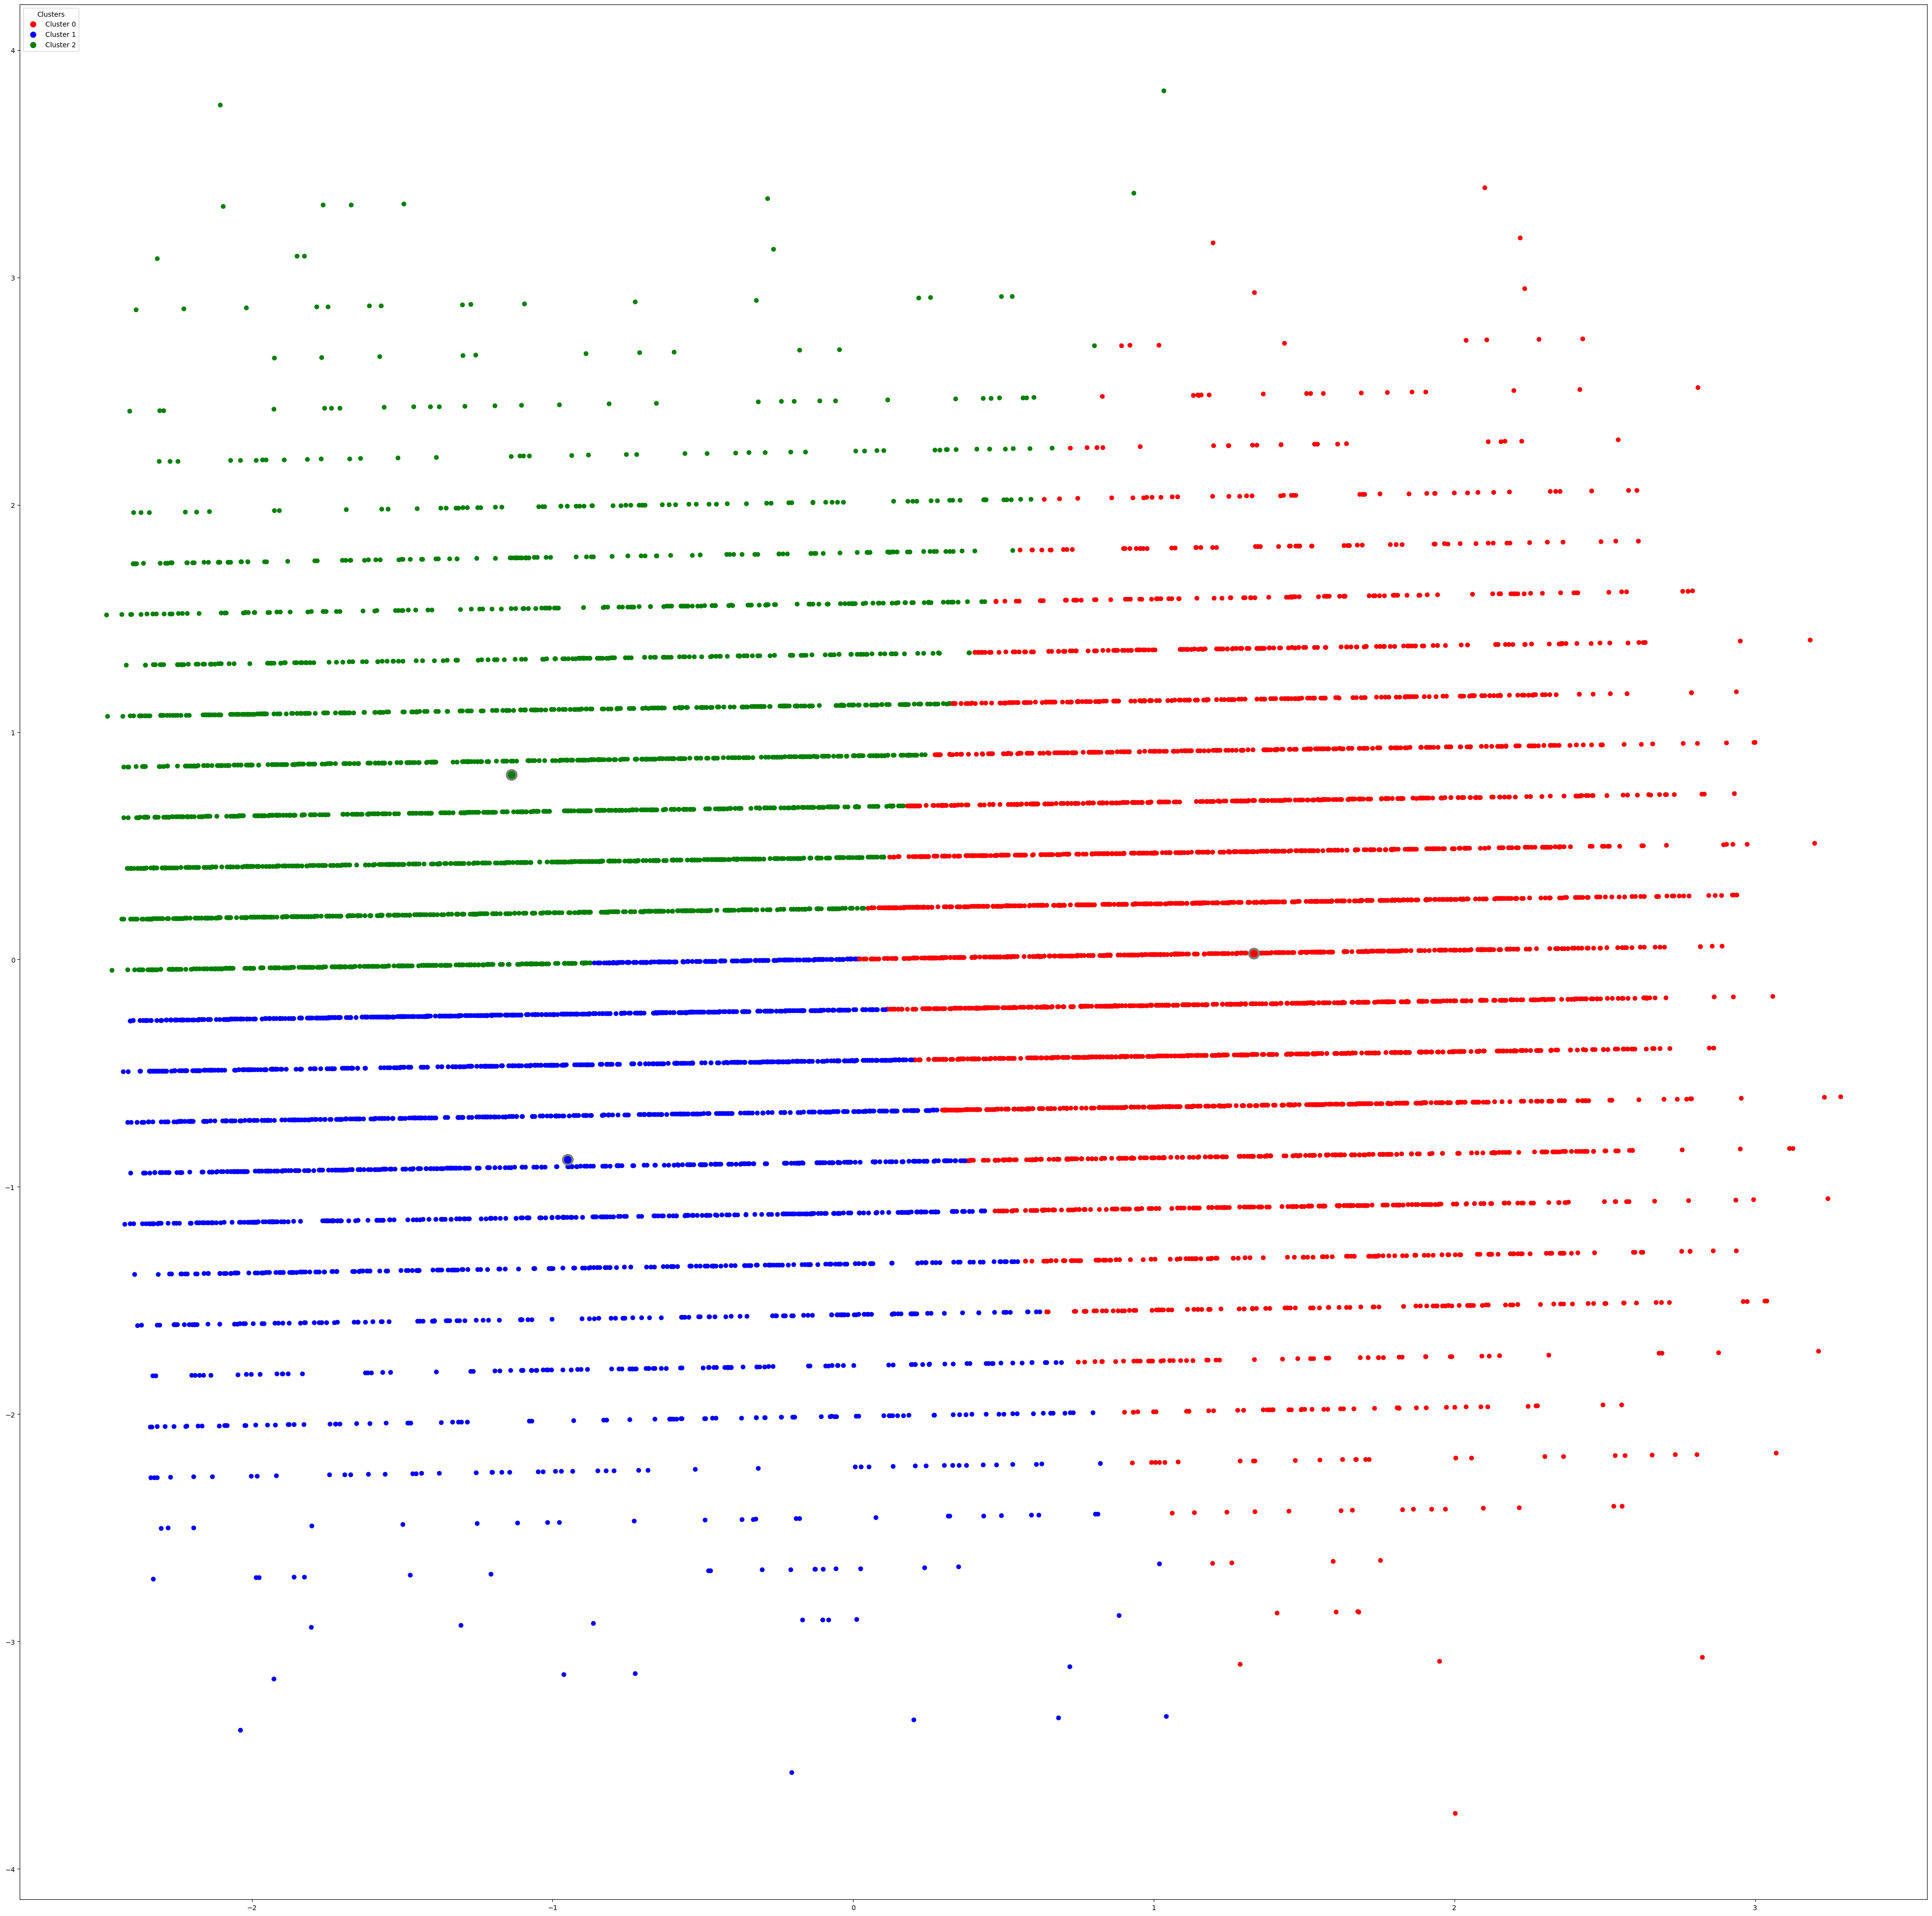

In [15]:
print(X_pca)
kmeans = KMeans(n_clusters=3, data=X_pca)
kmeans.showPlot(classification=True)
kmeans.printCentroids()
kmeans.fit(epochs=100, step=1)
pred = kmeans.genLabels()
print(pred)
kmeans.printCentroids()
kmeans.showPlot(classification=True)
pred = kmeans.predict([10000, 10000])
# print(f"Thuật toán KMean dự đoán điểm dữ liệu [10000, 10000] là {pred} có màu {kmeans.colors[pred]}")